# 📦 Data Collector — CliffWalking-v1

Collecte **100 000 steps**, politique mixte.

Outputs (1 fichier par type, splits intégrés) :
- `transitions.npz`
- `sequences_n5.npz`
- `deltas.npz`
- `scaler.npz`
- `metadata.json`

## 1. Imports & Configuration

In [106]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os, json, random
from collections import deque
from datetime import datetime
from gymnasium.wrappers import TimeLimit

 
# ── Configuration ─────────────────────────────────────────────────────────────
ENV_NAME      = "CliffWalking-v1"
# TOTAL_STEPS   = 100_000
N_STEPS       = 5
SAVE_DIR      = "collected/CliffWalking"
TRAIN_RATIO   = 0.70
VAL_RATIO     = 0.10
TEST_RATIO    = 0.20
 

# # ── Configuration MODIFIÉE ────────────────────────────────────────────────────
# TRAINED_RATIO = 0.40     # ↓ 40% DQN, 60% random (plus d'exploration)
# EPSILON_START = 1.0      # 100% random au début
# EPSILON_END   = 0.10     # 10% minimum (garantir exploration)
# EPSILON_DECAY = 0.995    # Decay plus lent
# TRAIN_START   =   500    # ↓ commencer à entraîner plus tôt
# BUFFER_SIZE   = 20_000   # ↓ buffer plus petit pour turnover plus rapide

# Configuration OPTIMISÉE pour CliffWalking
TOTAL_STEPS     = 200_000
TRAINED_RATIO   = 0.0       # ← 100% random pour collecte de couverture complète
EPSILON_START   = 1.0
EPSILON_END     = 1.0       # ← toujours random
EPSILON_DECAY   = 1.0       # ← pas de decay
TRAIN_START     = 10_000    # ← entraîner après avoir collecté assez de données
BUFFER_SIZE     = 50_000


# TRAINED_RATIO = 0.6     # 60% des steps utilisent le DQN, 40% random
LR            = 5e-4
GAMMA         = 0.99
# EPSILON_START = 1.0
# EPSILON_END   = 0.05
# EPSILON_DECAY = 0.997
BATCH_SIZE    = 128
# BUFFER_SIZE   = 50_000
TARGET_UPDATE = 300
# TRAIN_START   = 1_000
SEED          = 42
 
# ── Constantes spécifiques à CliffWalking ─────────────────────────────────────
GRID_ROWS   = 4
GRID_COLS   = 12
N_STATES    = GRID_ROWS * GRID_COLS   # 48 états discrets
N_ACTIONS   = 4
ACTION_LABELS = ["up (0)", "right (1)", "down (2)", "left (3)"]

 
os.makedirs(SAVE_DIR, exist_ok=True)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f"✅ Config OK — {ENV_NAME} | {TOTAL_STEPS:,} steps | n={N_STEPS}")
print(f"   Grille {GRID_ROWS}×{GRID_COLS} = {N_STATES} états | {N_ACTIONS} actions")


✅ Config OK — CliffWalking-v1 | 200,000 steps | n=5
   Grille 4×12 = 48 états | 4 actions


## 2. Environnement

In [107]:
env = gym.make(ENV_NAME)
env = TimeLimit(env, max_episode_steps=200)
env.action_space.seed(SEED)
 
# CliffWalking : observation = entier scalaire (0..47)
STATE_DIM    = N_STATES    # dimension one-hot utilisée dans les réseaux
ACTION_DIM   = N_ACTIONS
STATE_LABELS  = [f"cell_{i}" for i in range(N_STATES)]   # 48 cellules
ACTION_LABELS = ["up (0)", "right (1)", "down (2)", "left (3)"]
 
# Helpers : conversion état discret ↔ coordonnées grille
def state_to_rc(s):
    """Entier 0-47 → (row, col)"""
    return divmod(s, GRID_COLS)
 
def is_cliff(s):
    """True si la cellule est une falaise."""
    r, c = state_to_rc(s)
    return (r == 3) and (1 <= c <= 10)
 
def one_hot_state(s, n=N_STATES):
    """Entier → vecteur one-hot float32 (N_STATES,)"""
    oh = np.zeros(n, dtype=np.float32)
    oh[s] = 1.0
    return oh

def apply_action_to_state(s, a):
    r, c = state_to_rc(s)

    if a == 0:      # up
        nr, nc = max(0, r - 1), c

    elif a == 1:    # right
        nr, nc = r, min(GRID_COLS - 1, c + 1)

    elif a == 2:    # down
        nr, nc = min(GRID_ROWS - 1, r + 1), c

    else:           # left
        nr, nc = r, max(0, c - 1)

    return nr * GRID_COLS + nc

def is_cliff_state(s):
    """True si la cellule est une falaise."""
    r, c = state_to_rc(s)
    return (r == 3) and (1 <= c <= 10)
 
print(f"🎮 {ENV_NAME}  |  state_oh={STATE_DIM}D  |  actions={ACTION_DIM}")
print(f"   Start=36 (bas-gauche) | Goal=47 (bas-droite) | Falaises=37-46")

🎮 CliffWalking-v1  |  state_oh=48D  |  actions=4
   Start=36 (bas-gauche) | Goal=47 (bas-droite) | Falaises=37-46


## 3. DQN

In [108]:
class QNetwork(nn.Module):
    """
    Réseau Q pour CliffWalking.
    Input : état one-hot (48) concaténé à l'action one-hot (4) → 52D
    Output: Q-valeurs pour chaque action (4)
    
    Note : on utilise le one-hot en entrée plutôt que l'entier brut
    pour éviter que le réseau interprète l'état comme une grandeur ordinale.
    """
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )
    def forward(self, x):
        return self.net(x)
 
 
class ReplayBuffer:
    """Buffer circulaire. Stocke les états en one-hot float32."""
    def __init__(self, cap):
        self.buf = deque(maxlen=cap)
 
    def push(self, s_oh, a, r, ns_oh, d):
        self.buf.append((s_oh, a, r, ns_oh, d))
 
    def sample(self, n):
        b = random.sample(self.buf, n)
        s, a, r, ns, d = zip(*b)
        return (torch.FloatTensor(np.array(s)),
                torch.LongTensor(a),
                torch.FloatTensor(r),
                torch.FloatTensor(np.array(ns)),
                torch.FloatTensor(d))
 
    def __len__(self):
        return len(self.buf)
 
 
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
q_net      = QNetwork(STATE_DIM, ACTION_DIM).to(device)
target_net = QNetwork(STATE_DIM, ACTION_DIM).to(device)
target_net.load_state_dict(q_net.state_dict())
optimizer  = optim.Adam(q_net.parameters(), lr=LR)
replay_buf = ReplayBuffer(BUFFER_SIZE)
epsilon    = EPSILON_START
print(f"🧠 DQN sur {device} | params={sum(p.numel() for p in q_net.parameters()):,}")

🧠 DQN sur cpu | params=23,300


## 4. Helpers

In [109]:
def select_action(state_oh, eps, use_trained=True):
    """
    Politique mixte :
    - use_trained=True  → ε-greedy sur Q-network (input one-hot)
    - use_trained=False → random pur
    """
    if not use_trained or random.random() < eps:
        return env.action_space.sample()
    with torch.no_grad():
        t = torch.FloatTensor(state_oh).unsqueeze(0).to(device)
        return q_net(t).argmax(1).item()
 
 
def train_step():
    """Un pas de mise à jour DQN (Double DQN)."""
    if len(replay_buf) < BATCH_SIZE:
        return None
    s, a, r, ns, d = [x.to(device) for x in replay_buf.sample(BATCH_SIZE)]
 
    q = q_net(s).gather(1, a.unsqueeze(1)).squeeze(1)
 
    with torch.no_grad():
        best = q_net(ns).argmax(1, keepdim=True)
        tgt  = r + GAMMA * target_net(ns).gather(1, best).squeeze(1) * (1 - d)
 
    loss = nn.SmoothL1Loss()(q, tgt)
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(q_net.parameters(), 1.0)
    optimizer.step()
    return loss.item()
 
 
print("✅ Helpers définis")

✅ Helpers définis


## 5. Collecte Principale — 100 000 Steps

In [110]:
# ── BOUCLE DE COLLECTE CORRIGÉE (Section 5) ───────────────────────────────────

all_episodes, cur_ep = [], []
step_count = episode_count = 0
ep_reward  = 0
rewards_log = []

# FORÇER beaucoup plus d'épisodes en collectant jusqu'à 500 épisodes
MAX_EPISODES = 3000  # ← AJOUTÉ

raw_state, _ = env.reset(seed=SEED)
state_oh = one_hot_state(raw_state)

print(f"🚀 Collecte {TOTAL_STEPS:,} steps ou {MAX_EPISODES} épisodes...")
print("-" * 65)

while step_count < TOTAL_STEPS and episode_count < MAX_EPISODES:
    # Plus d'exploration au début
    use_trained = (random.random() < TRAINED_RATIO) and (step_count >= TRAIN_START)
    action      = select_action(state_oh, epsilon, use_trained)

    raw_ns, reward, term, trunc, _ = env.step(action)
    if reward == -100:
        print("CLIFF:", term, trunc, raw_ns)

    done = term or trunc

    # état théorique avant reset automatique
    theoretical_next = apply_action_to_state(raw_state, action)

    fell_off_cliff = (reward == -100)

    if fell_off_cliff and is_cliff_state(theoretical_next):
        stored_next_state = theoretical_next
    else:
        stored_next_state = raw_ns

    ns_oh = one_hot_state(stored_next_state)

    # Stockage CORRECT
    cur_ep.append(dict(
        state           = raw_state,
        state_oh        = state_oh.copy(),
        action          = int(action),
        reward          = float(reward),
        next_state      = stored_next_state,
        next_state_oh   = ns_oh.copy(),
        done            = bool(done),
        fell_off_cliff  = bool(fell_off_cliff),
        episode_id      = episode_count,
    ))

    replay_buf.push(state_oh, action, reward, ns_oh, float(done))
    if step_count >= TRAIN_START:
        train_step()
    if step_count % TARGET_UPDATE == 0:
        target_net.load_state_dict(q_net.state_dict())

    ep_reward  += reward
    raw_state = raw_ns
    state_oh = one_hot_state(raw_ns)
    step_count += 1

    if done:
        all_episodes.append(cur_ep)
        rewards_log.append(ep_reward)
        cur_ep = []
        ep_reward = 0
        episode_count += 1
        epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)
        
        # RESET explicite
        raw_state, _ = env.reset()
        state_oh = one_hot_state(raw_state)
        
        if episode_count % 50 == 0:
            avg = np.mean(rewards_log[-100:]) if len(rewards_log) >= 100 else np.mean(rewards_log)
            print(f"  ep {episode_count:4d} | steps {step_count:7,} | avg={avg:8.1f} | ε={epsilon:.3f} | len_ep={len(all_episodes[-1])}")

if cur_ep:
    all_episodes.append(cur_ep)

env.close()
print("-" * 65)
print(f"✅ {step_count:,} steps | {episode_count} épisodes")
print(f"   reward_mean={np.mean(rewards_log):.2f} | max={np.max(rewards_log):.2f} | min={np.min(rewards_log):.2f}")

# VÉRIFICATION : comptes par état
print("\n--- Distribution des états visités ---")
all_states = []
for ep in all_episodes:
    for step in ep:
        all_states.append(step['state'])
all_states = np.array(all_states)
for s in range(48):
    count = (all_states == s).sum()
    if count > 0 or s >= 37:  # Afficher tous les 37-47 même si 0
        print(f"  state {s:2d}: {count:6,} visits{' ← CLIFF/GOAL' if s >= 37 else ''}")


# all_episodes, cur_ep = [], []
# step_count = episode_count = 0
# ep_reward  = 0
# rewards_log = []
 
# raw_state, _ = env.reset(seed=SEED)
# state_oh = one_hot_state(raw_state)   # représentation utilisée par le réseau
# print(f"🚀 Collecte {TOTAL_STEPS:,} steps...")
# print("-" * 65)
 
# while step_count < TOTAL_STEPS:
#     use_trained = (random.random() < TRAINED_RATIO) and (step_count >= TRAIN_START)
#     action      = select_action(state_oh, epsilon, use_trained)
 
#     # raw_ns, reward, term, trunc, _ = env.step(action)
#     # done    = term or trunc
#     # ns_oh   = one_hot_state(raw_ns)
 
#     # # Stockage : état brut (int) ET one-hot
#     # cur_ep.append(dict(
#     #     state      = raw_state,          # entier 0-47
#     #     state_oh   = state_oh.copy(),    # one-hot (48,)
#     #     action     = int(action),
#     #     reward     = float(reward),
#     #     next_state = raw_ns,
#     #     next_state_oh = ns_oh.copy(),
#     #     done       = bool(done),
#     #     episode_id = episode_count,
#     # ))



#     raw_ns, reward, term, trunc, info = env.step(action)
#     done = term or trunc

#     # DEBUG: détecter si on est tombé dans la falaise
#     fell_off_cliff = (reward == -100)

#     # Si on est tombé dans la falaise, Gymnasium a déjà reset à state 36
#     # mais on veut ENREGISTRER que l'action a mené À la falaise (état 37-46)
#     # Pour ça, on calcule manuellement quel état DEVAIT être le next_state
#     def apply_action_to_state(s, a):
#         """Applique manuellement l'action pour obtenir l'état théorique (avant reset auto)"""
#         r, c = divmod(s, GRID_COLS)
#         if a == 0:  # up
#             nr, nc = max(0, r-1), c
#         elif a == 1:  # right
#             nr, nc = r, min(GRID_COLS-1, c+1)
#         elif a == 2:  # down
#             nr, nc = min(GRID_ROWS-1, r+1), c
#         elif a == 3:  # left
#             nr, nc = r, max(0, c-1)
#         return nr * GRID_COLS + nc

#     # Calculer le next_state théorique (avant reset auto de Gym)
#     theoretical_next = apply_action_to_state(raw_state, action)
#     is_cliff_next = is_cliff(theoretical_next)

#     # Si c'est une falaise, on stocke l'état de falaise comme next_state
#     # (même si Gym a déjà reset à 36)
#     if fell_off_cliff and is_cliff_next:
#         actual_next_state = theoretical_next  # 37-46 (état de falaise)
#     else:
#         actual_next_state = raw_ns  # état réel retourné par Gym

#     ns_oh = one_hot_state(actual_next_state)

#     # Stockage CORRECTÉ
#     cur_ep.append(dict(
#         state           = raw_state,
#         state_oh        = state_oh.copy(),
#         action          = int(action),
#         reward          = float(reward),
#         next_state      = actual_next_state,  # CORRECTÉ: peut être 37-46
#         next_state_oh   = ns_oh.copy(),
#         done            = bool(done),
#         fell_off_cliff  = fell_off_cliff,     # DEBUG flag
#         episode_id      = episode_count,
#     ))



 
#     replay_buf.push(state_oh, action, reward, ns_oh, float(done))
#     if step_count >= TRAIN_START:
#         train_step()
#     if step_count % TARGET_UPDATE == 0:
#         target_net.load_state_dict(q_net.state_dict())
 
#     ep_reward  += reward
#     raw_state   = raw_ns
#     state_oh    = ns_oh
#     step_count += 1
 
#     if done:
#         all_episodes.append(cur_ep)
#         rewards_log.append(ep_reward)
#         cur_ep = []; ep_reward = 0; episode_count += 1
#         epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)
#         raw_state, _ = env.reset()
#         state_oh = one_hot_state(raw_state)
#         if episode_count % 100 == 0:
#             avg = np.mean(rewards_log[-100:])
#             print(f"  ep {episode_count:4d} | steps {step_count:7,} | avg100={avg:8.1f} | ε={epsilon:.3f}")
 
# if cur_ep :
#     all_episodes.append(cur_ep)
# env.close()
# print("-" * 65)
# print(f"✅ {step_count:,} steps | {episode_count} épisodes")
# print(f"   reward_mean={np.mean(rewards_log):.2f} | max={np.max(rewards_log):.2f} | min={np.min(rewards_log):.2f}")

🚀 Collecte 200,000 steps ou 3000 épisodes...
-----------------------------------------------------------------
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: False False 36
CLIFF: Fa

In [123]:
print("\n--- Cliff coverage ---")

cliff_hits = 0

for ep in all_episodes:
    for step in ep:
        ns = step["next_state"]

        if 37 <= ns <= 46:
            cliff_hits += 1

print("Cliff transitions:", cliff_hits)

visited = set()

for ep in all_episodes:
    for step in ep:
        visited.add(step["state"])
        visited.add(step["next_state"])

print("Visited states:", len(visited), "/48")

missing = sorted(set(range(48)) - visited)

print("Missing:", missing)


--- Cliff coverage ---
Cliff transitions: 19251
Visited states: 48 /48
Missing: []


In [112]:
goal_count = 0

for ep in all_episodes:
    for step in ep:
        if step["next_state"] == 47:
            goal_count += 1

print(goal_count)

29


In [113]:
cliff_examples = []

for ep in all_episodes:
    for step in ep:
        if step["fell_off_cliff"]:
            cliff_examples.append(
                (
                    step["state"],
                    step["action"],
                    step["next_state"],
                    step["reward"]
                )
            )

print("nb cliff examples =", len(cliff_examples))

for x in cliff_examples[:20]:
    print(x)

nb cliff examples = 19251
(36, 1, 37, -100.0)
(36, 1, 37, -100.0)
(25, 2, 37, -100.0)
(36, 1, 37, -100.0)
(36, 1, 37, -100.0)
(36, 1, 37, -100.0)
(36, 1, 37, -100.0)
(26, 2, 38, -100.0)
(36, 1, 37, -100.0)
(36, 1, 37, -100.0)
(36, 1, 37, -100.0)
(36, 1, 37, -100.0)
(26, 2, 38, -100.0)
(25, 2, 37, -100.0)
(25, 2, 37, -100.0)
(36, 1, 37, -100.0)
(25, 2, 37, -100.0)
(36, 1, 37, -100.0)
(36, 1, 37, -100.0)
(36, 1, 37, -100.0)


## 6. Learning Curve

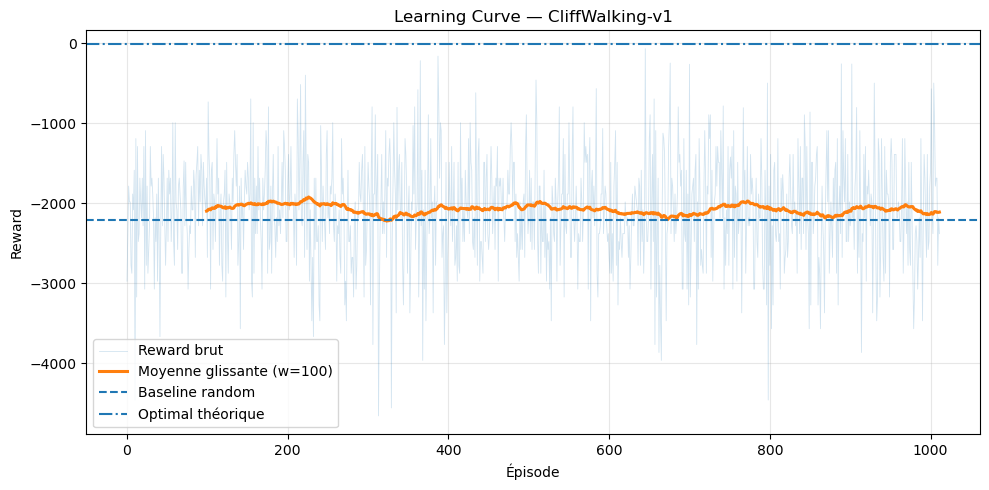

📈 Saved → collected/CliffWalking/learning_curve.png


In [114]:
def plot_learning_curve(rewards, window=100, env_name=ENV_NAME, save_dir=SAVE_DIR):
    rewards = np.array(rewards)
    episodes = np.arange(len(rewards))

    # sécurité si pas assez d'épisodes
    window = min(window, len(rewards)) if len(rewards) > 0 else 1

    ma = np.convolve(rewards, np.ones(window) / window, mode='valid')
    ma_ep = episodes[window - 1:] if len(ma) > 0 else []

    random_baseline = float(np.mean(rewards[:max(20, int(len(rewards) * 0.05))])) if len(rewards) > 0 else 0
    optimal_ref = -13.0

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(episodes, rewards, alpha=0.2, linewidth=0.6, label="Reward brut")

    if len(ma) > 0:
        ax.plot(ma_ep, ma, linewidth=2.2, label=f"Moyenne glissante (w={window})")

    ax.axhline(random_baseline, linestyle="--", label="Baseline random")
    ax.axhline(optimal_ref, linestyle="-.", label="Optimal théorique")

    ax.set_title(f"Learning Curve — {env_name}")
    ax.set_xlabel("Épisode")
    ax.set_ylabel("Reward")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    path = os.path.join(save_dir, "learning_curve.png")
    plt.savefig(path, dpi=150)
    plt.show()

    print(f"📈 Saved → {path}")

plot_learning_curve(rewards_log)

## 7. Split Train / Val / Test par Épisodes

In [115]:
# ⚠️ On shuffle les ÉPISODES, pas les transitions individuelles
random.seed(SEED)
ep_indices = list(range(len(all_episodes)))
random.shuffle(ep_indices)
 
n_total = len(ep_indices)
n_train = int(n_total * TRAIN_RATIO)
n_val   = int(n_total * VAL_RATIO)
 
train_ep_idx = ep_indices[:n_train]
val_ep_idx   = ep_indices[n_train:n_train + n_val]
test_ep_idx  = ep_indices[n_train + n_val:]
 
print(f"📂 Split épisodes → train={len(train_ep_idx)} | val={len(val_ep_idx)} | test={len(test_ep_idx)}")
 
 
def episodes_to_arrays(ep_idx_list):
    """
    Convertit une liste d'indices d'épisodes en arrays numpy.
    Retourne : états (int), états one-hot, actions, rewards, next_states (int),
               next_states one-hot, dones, episode_ids.
    """
    S_int, S_oh, A, R, NS_int, NS_oh, D, E_ID = [], [], [], [], [], [], [], []
    for idx in ep_idx_list:
        for step in all_episodes[idx]:
            S_int.append(step["state"])
            S_oh.append(step["state_oh"])
            A.append(step["action"])
            R.append(step["reward"])
            NS_int.append(step["next_state"])
            NS_oh.append(step["next_state_oh"])
            D.append(step["done"])
            E_ID.append(step["episode_id"])
    return (
        np.array(S_int,  dtype=np.int32),
        np.array(S_oh,   dtype=np.float32),    # (N, 48)
        np.array(A,      dtype=np.int32),
        np.array(R,      dtype=np.float32),
        np.array(NS_int, dtype=np.int32),
        np.array(NS_oh,  dtype=np.float32),    # (N, 48)
        np.array(D,      dtype=np.bool_),
        np.array(E_ID,   dtype=np.int32),
    )
 
 
(S_tr_int, S_tr_oh, A_tr, R_tr, NS_tr_int, NS_tr_oh, D_tr, E_ID_tr) = episodes_to_arrays(train_ep_idx)
(S_va_int, S_va_oh, A_va, R_va, NS_va_int, NS_va_oh, D_va, E_ID_va) = episodes_to_arrays(val_ep_idx)
(S_te_int, S_te_oh, A_te, R_te, NS_te_int, NS_te_oh, D_te, E_ID_te) = episodes_to_arrays(test_ep_idx)
 
print(f"   Train steps : {len(S_tr_oh):,}")
print(f"   Val   steps : {len(S_va_oh):,}")
print(f"   Test  steps : {len(S_te_oh):,}")

📂 Split épisodes → train=709 | val=101 | test=203
   Train steps : 140,038
   Val   steps : 19,614
   Test  steps : 40,348


## 8. Normalisation (z-score, stats TRAIN only)

In [116]:
# =============================================================================
# ── CliffWalking : états one-hot ∈ {0,1} → pas de z-score utile.
#    On conserve le one-hot brut comme représentation principale.
#    Pour les rewards, on calcule mean/std sur TRAIN uniquement (utile pour
#    les architectures qui prédisent des rewards).
# ──────────────────────────────────────────────────────────────────────────────
 
reward_mean = float(R_tr.mean())
reward_std  = float(R_tr.std() + 1e-8)
 
def norm_r(r): return (r - reward_mean) / reward_std
 
R_tr_n = norm_r(R_tr)
R_va_n = norm_r(R_va)
R_te_n = norm_r(R_te)
 
# Deltas one-hot : NS_oh - S_oh (vecteurs creux, valeurs ∈ {-1, 0, +1})
D_tr_oh = NS_tr_oh - S_tr_oh   # (N, 48)
D_va_oh = NS_va_oh - S_va_oh
D_te_oh = NS_te_oh - S_te_oh
 
# One-hot actions
def one_hot_actions(a, n=ACTION_DIM):
    oh = np.zeros((len(a), n), dtype=np.float32)
    oh[np.arange(len(a)), a] = 1.0
    return oh
 
A_tr_oh = one_hot_actions(A_tr)
A_va_oh = one_hot_actions(A_va)
A_te_oh = one_hot_actions(A_te)
 
print("✅ Normalisation OK")
print(f"   reward_mean (train) : {reward_mean:.4f}")
print(f"   reward_std  (train) : {reward_std:.4f}")
 
# Sauvegarde scaler
np.savez_compressed(os.path.join(SAVE_DIR, "scaler.npz"),
    reward_mean=np.array(reward_mean),
    reward_std=np.array(reward_std),
    # Pas de state_mean/std : one-hot ne se normalise pas en z-score
    n_states=np.array(N_STATES),
    n_actions=np.array(N_ACTIONS),
)
print("💾 scaler.npz sauvegardé")
 

✅ Normalisation OK
   reward_mean (train) : -10.5898
   reward_std  (train) : 29.2818
💾 scaler.npz sauvegardé


## 9. Sauvegarde — transitions.npz

In [117]:
transitions = {
    # TRAIN
    "states_int_train"        : S_tr_int,        # (N,)   entier 0-47
    "states_train"            : S_tr_oh,          # (N,48) one-hot
    "actions_train"           : A_tr,             # (N,)
    "actions_onehot_train"    : A_tr_oh,          # (N,4)
    "rewards_train"           : R_tr,             # (N,)   raw
    "rewards_norm_train"      : R_tr_n,           # (N,)   normalisés
    "next_states_int_train"   : NS_tr_int,        # (N,)
    "next_states_train"       : NS_tr_oh,         # (N,48)
    "dones_train"             : D_tr,
    "episode_ids_train"       : E_ID_tr,
    # VAL
    "states_int_val"          : S_va_int,
    "states_val"              : S_va_oh,
    "actions_val"             : A_va,
    "actions_onehot_val"      : A_va_oh,
    "rewards_val"             : R_va,
    "rewards_norm_val"        : R_va_n,
    "next_states_int_val"     : NS_va_int,
    "next_states_val"         : NS_va_oh,
    "dones_val"               : D_va,
    "episode_ids_val"         : E_ID_va,
    # TEST
    "states_int_test"         : S_te_int,
    "states_test"             : S_te_oh,
    "actions_test"            : A_te,
    "actions_onehot_test"     : A_te_oh,
    "rewards_test"            : R_te,
    "rewards_norm_test"       : R_te_n,
    "next_states_int_test"    : NS_te_int,
    "next_states_test"        : NS_te_oh,
    "dones_test"              : D_te,
    "episode_ids_test"        : E_ID_te,
}
np.savez_compressed(os.path.join(SAVE_DIR, "transitions.npz"), **transitions)
print("✅ transitions.npz sauvegardé")
print("\nTRAIN")
print("  states_train     :", transitions["states_train"].shape, "  (one-hot)")
print("  states_int_train :", transitions["states_int_train"].shape, "(entier)")
print("  next_states_train:", transitions["next_states_train"].shape)
print("\nVAL");  print("  states_val       :", transitions["states_val"].shape)
print("\nTEST"); print("  states_test      :", transitions["states_test"].shape)

✅ transitions.npz sauvegardé

TRAIN
  states_train     : (140038, 48)   (one-hot)
  states_int_train : (140038,) (entier)
  next_states_train: (140038, 48)

VAL
  states_val       : (19614, 48)

TEST
  states_test      : (40348, 48)


## 10. Sauvegarde — sequences_n5.npz

In [118]:
def extract_sequences(ep_idx_list, n=N_STEPS):
    """
    Fenêtre glissante sur les épisodes d'un split.
    Ignore les fenêtres traversant une frontière done=True.
    Retourne : états one-hot, états int, actions int, actions one-hot,
               rewards raw, état_n one-hot, état_n int, episode_ids.
    """
    seq_s_oh, seq_s_int = [], []
    seq_a, seq_a_oh     = [], []
    seq_r               = []
    seq_sn_oh, seq_sn_int = [], []
    seq_e_id            = []
 
    for idx in ep_idx_list:
        ep = all_episodes[idx]
        for i in range(len(ep) - n + 1):
            window = ep[i:i + n]
            if any(w["done"] for w in window[:-1]):
                continue
            if window[-1]["done"]:
                continue
            seq_s_oh.append(window[0]["state_oh"])
            seq_s_int.append(window[0]["state"])
            acts = [w["action"] for w in window]
            seq_a.append(acts)
            oh = np.zeros((n, ACTION_DIM), dtype=np.float32)
            for t, ac in enumerate(acts):
                oh[t, ac] = 1.0
            seq_a_oh.append(oh)
            seq_r.append([w["reward"] for w in window])
            seq_sn_oh.append(window[-1]["next_state_oh"])
            seq_sn_int.append(window[-1]["next_state"])
            seq_e_id.append([w["episode_id"] for w in window])
 
    return (
        np.array(seq_s_oh,   dtype=np.float32),
        np.array(seq_s_int,  dtype=np.int32),
        np.array(seq_a,      dtype=np.int32),
        np.array(seq_a_oh,   dtype=np.float32),
        np.array(seq_r,      dtype=np.float32),
        np.array(seq_sn_oh,  dtype=np.float32),
        np.array(seq_sn_int, dtype=np.int32),
        np.array(seq_e_id,   dtype=np.int32),
    )
 
 
(seq_s_oh_tr, seq_s_int_tr, seq_a_tr, seq_aoh_tr,
 seq_r_tr, seq_sn_oh_tr, seq_sn_int_tr, seq_eid_tr) = extract_sequences(train_ep_idx)
 
(seq_s_oh_va, seq_s_int_va, seq_a_va, seq_aoh_va,
 seq_r_va, seq_sn_oh_va, seq_sn_int_va, seq_eid_va) = extract_sequences(val_ep_idx)
 
(seq_s_oh_te, seq_s_int_te, seq_a_te, seq_aoh_te,
 seq_r_te, seq_sn_oh_te, seq_sn_int_te, seq_eid_te) = extract_sequences(test_ep_idx)
 
sequences = {
    # TRAIN
    "states_train"            : seq_s_oh_tr,
    "states_int_train"        : seq_s_int_tr,
    "actions_train"           : seq_a_tr,
    "actions_onehot_train"    : seq_aoh_tr,
    "rewards_train"           : seq_r_tr,
    "states_n_train"          : seq_sn_oh_tr,
    "states_n_int_train"      : seq_sn_int_tr,
    "episode_ids_train"       : seq_eid_tr,
    # VAL
    "states_val"              : seq_s_oh_va,
    "states_int_val"          : seq_s_int_va,
    "actions_val"             : seq_a_va,
    "actions_onehot_val"      : seq_aoh_va,
    "rewards_val"             : seq_r_va,
    "states_n_val"            : seq_sn_oh_va,
    "states_n_int_val"        : seq_sn_int_va,
    "episode_ids_val"         : seq_eid_va,
    # TEST
    "states_test"             : seq_s_oh_te,
    "states_int_test"         : seq_s_int_te,
    "actions_test"            : seq_a_te,
    "actions_onehot_test"     : seq_aoh_te,
    "rewards_test"            : seq_r_te,
    "states_n_test"           : seq_sn_oh_te,
    "states_n_int_test"       : seq_sn_int_te,
    "episode_ids_test"        : seq_eid_te,
    "n_steps"                 : np.array([N_STEPS]),
}
np.savez_compressed(os.path.join(SAVE_DIR, "sequences_n5.npz"), **sequences)
print("✅ sequences_n5.npz sauvegardé")
print("\nTRAIN")
print("  states_train    :", sequences["states_train"].shape, "  (M, 48)")
print("  states_n_train  :", sequences["states_n_train"].shape)
print("  actions_onehot  :", sequences["actions_onehot_train"].shape, "→ (M, n, 4)")
print("\nVAL");  print("  states_val      :", sequences["states_val"].shape)
print("\nTEST"); print("  states_test     :", sequences["states_test"].shape)

✅ sequences_n5.npz sauvegardé

TRAIN
  states_train    : (136493, 48)   (M, 48)
  states_n_train  : (136493, 48)
  actions_onehot  : (136493, 5, 4) → (M, n, 4)

VAL
  states_val      : (19110, 48)

TEST
  states_test     : (39333, 48)


## 11. Sauvegarde — deltas.npz

In [119]:
# =============================================================================
# Dans CliffWalking, le delta one-hot représente le changement de cellule :
#   D[i] = NS_oh[i] - S_oh[i]  → vecteur creux avec -1 (cellule quittée),
#                                  +1 (cellule atteinte), 0 ailleurs.
# C'est utile pour entraîner un modèle de transition symbolique.
# ──────────────────────────────────────────────────────────────────────────────
deltas = {
    # TRAIN
    "states_train"          : S_tr_oh,
    "states_int_train"      : S_tr_int,
    "actions_train"         : A_tr,
    "actions_onehot_train"  : A_tr_oh,
    "deltas_train"          : D_tr_oh,       # NS_oh - S_oh
    "rewards_train"         : R_tr,
    "rewards_norm_train"    : R_tr_n,
    "episode_ids_train"     : E_ID_tr,
    # VAL
    "states_val"            : S_va_oh,
    "states_int_val"        : S_va_int,
    "actions_val"           : A_va,
    "actions_onehot_val"    : A_va_oh,
    "deltas_val"            : D_va_oh,
    "rewards_val"           : R_va,
    "rewards_norm_val"      : R_va_n,
    "episode_ids_val"       : E_ID_va,
    # TEST
    "states_test"           : S_te_oh,
    "states_int_test"       : S_te_int,
    "actions_test"          : A_te,
    "actions_onehot_test"   : A_te_oh,
    "deltas_test"           : D_te_oh,
    "rewards_test"          : R_te,
    "rewards_norm_test"     : R_te_n,
    "episode_ids_test"      : E_ID_te,
}
np.savez_compressed(os.path.join(SAVE_DIR, "deltas.npz"), **deltas)
print("✅ deltas.npz sauvegardé")
print("\nTRAIN")
print("  states_train :", deltas["states_train"].shape)
print("  deltas_train :", deltas["deltas_train"].shape, " (NS_oh - S_oh)")
print("\nVAL");  print("  deltas_val   :", deltas["deltas_val"].shape)
print("\nTEST"); print("  deltas_test  :", deltas["deltas_test"].shape)

✅ deltas.npz sauvegardé

TRAIN
  states_train : (140038, 48)
  deltas_train : (140038, 48)  (NS_oh - S_oh)

VAL
  deltas_val   : (19614, 48)

TEST
  deltas_test  : (40348, 48)


## 12. analyze_dataset


--- Statistiques (train) ---
  Steps          : 140,038
  Reward mean    : -10.590  std=29.282
  Reward -100    : 13,565 (9.7%  falaises)
  Reward -1      : 126,473
  États uniques  : 37/48
  Actions : up (0)=34,663 | right (1)=35,131 | down (2)=35,248 | left (3)=34,996


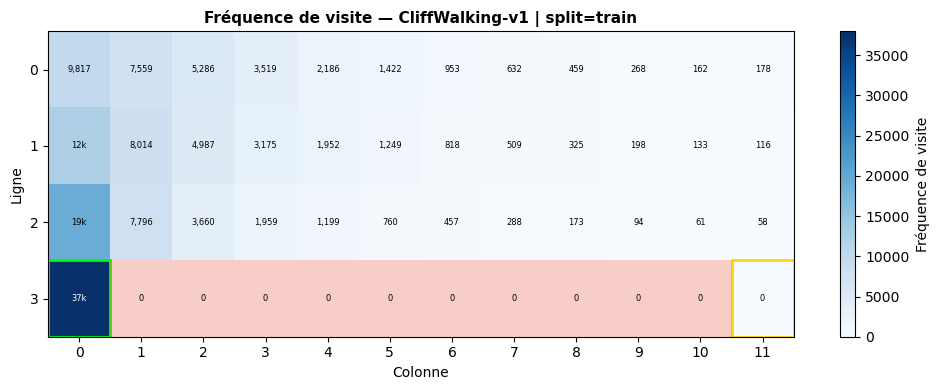

📊 Heatmap sauvegardée → collected/CliffWalking/grid_heatmap_train.png


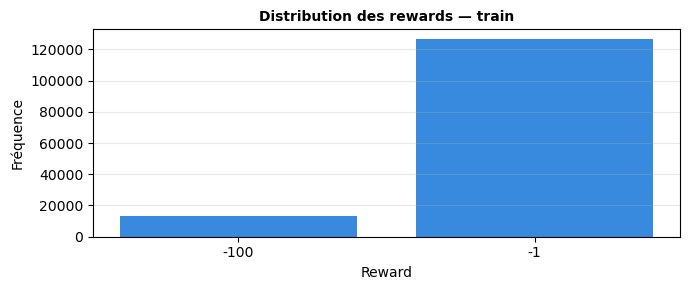

📊 Distribution rewards → collected/CliffWalking/reward_dist_train.png


In [120]:
def plot_grid_heatmap(s_int, title, save_path):
    """Heatmap de fréquence de visite sur la grille 4×12."""
    counts = np.bincount(s_int, minlength=N_STATES).reshape(GRID_ROWS, GRID_COLS)
    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(counts, cmap="Blues", aspect="auto")
    plt.colorbar(im, ax=ax, label="Fréquence de visite")
 
    # Annotations
    for r in range(GRID_ROWS):
        for c in range(GRID_COLS):
            val = counts[r, c]
            ax.text(c, r, f"{val:,}" if val < 10000 else f"{val//1000}k",
                    ha="center", va="center", fontsize=6,
                    color="white" if val > counts.max() * 0.6 else "black")
 
    # Marqueurs spéciaux
    ax.add_patch(plt.Rectangle((-0.5, 2.5), 1, 1, fill=False, edgecolor="lime",   linewidth=2))  # Start≈36
    ax.add_patch(plt.Rectangle((10.5, 2.5), 1, 1, fill=False, edgecolor="gold",  linewidth=2))  # Goal≈47
    for c in range(1, 11):
        ax.add_patch(plt.Rectangle((c - 0.5, 2.5), 1, 1, fill=True, facecolor="tomato", alpha=0.3))
 
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Colonne"); ax.set_ylabel("Ligne")
    ax.set_xticks(range(GRID_COLS)); ax.set_yticks(range(GRID_ROWS))
    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"📊 Heatmap sauvegardée → {save_path}")
 
 
def analyze_dataset(s_int, s_oh, a, r, ns_oh, split_name="train", save_dir=SAVE_DIR):
    """Statistiques + visualisations pour un split."""
    print(f"\n--- Statistiques ({split_name}) ---")
    print(f"  Steps          : {len(s_int):,}")
    print(f"  Reward mean    : {r.mean():.3f}  std={r.std():.3f}")
    print(f"  Reward -100    : {(r == -100).sum():,} ({100*(r==-100).mean():.1f}%  falaises)")
    print(f"  Reward -1      : {(r == -1).sum():,}")
    print(f"  États uniques  : {len(np.unique(s_int))}/{N_STATES}")
 
    action_counts = np.bincount(a.reshape(-1).astype(np.int64), minlength=ACTION_DIM)
    print(f"  Actions : " + " | ".join(f"{ACTION_LABELS[i]}={action_counts[i]:,}" for i in range(ACTION_DIM)))
 
    # Heatmap fréquence
    plot_grid_heatmap(
        s_int,
        f"Fréquence de visite — {ENV_NAME} | split={split_name}",
        os.path.join(save_dir, f"grid_heatmap_{split_name}.png")
    )
 
    # Distribution des rewards
    fig, ax = plt.subplots(figsize=(7, 3))
    unique_r, counts_r = np.unique(r, return_counts=True)
    ax.bar([str(int(v)) for v in unique_r], counts_r, color="#378ADD", edgecolor="none")
    ax.set_title(f"Distribution des rewards — {split_name}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Reward"); ax.set_ylabel("Fréquence")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    path = os.path.join(save_dir, f"reward_dist_{split_name}.png")
    plt.savefig(path, dpi=130, bbox_inches="tight"); plt.show()
    print(f"📊 Distribution rewards → {path}")
 
 
analyze_dataset(S_tr_int, S_tr_oh, A_tr, R_tr, NS_tr_oh, split_name="train")

## 13. Métadonnées

In [121]:
def convert_numpy(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj)} is not JSON serializable")


metadata = {
    "env_name"         : ENV_NAME,
    "collection_date"  : datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "total_steps"      : int(step_count),
    "total_episodes"   : int(episode_count),
    "n_steps"          : N_STEPS,
    "trained_ratio"    : TRAINED_RATIO,
    "seed"             : SEED,
    # Espace d'états
    "state_type"       : "discrete",
    "n_states"         : N_STATES,
    "state_dim_onehot" : STATE_DIM,
    "grid_rows"        : GRID_ROWS,
    "grid_cols"        : GRID_COLS,
    "start_state"      : 36,
    "goal_state"       : 47,
    "cliff_states"     : list(range(37, 47)),
    # Actions
    "action_dim"       : ACTION_DIM,
    "action_labels"    : ACTION_LABELS,
    # Rewards
    "reward_step"      : -1,
    "reward_cliff"     : -100,
    "reward_optimal_episode" : -13,
    # Normalisation
    "normalization"    : {
        "states"  : "one-hot (pas de z-score)",
        "rewards" : "z-score (mean/std from train only)",
        "deltas"  : "NS_oh - S_oh (valeurs entières {-1,0,1})"
    },
    # Splits
    "split"            : {"train": TRAIN_RATIO, "val": VAL_RATIO, "test": TEST_RATIO},
    "n_episodes"       : {"train": len(train_ep_idx), "val": len(val_ep_idx), "test": len(test_ep_idx)},
    "n_steps_per_split": {"train": int(len(S_tr_oh)), "val": int(len(S_va_oh)), "test": int(len(S_te_oh))},
    # Policy
    "policy"           : f"mixed (DQN ε-greedy {int(TRAINED_RATIO*100)}% + random {int((1-TRAINED_RATIO)*100)}%)",
    "reward_stats"     : {
        "mean": float(np.mean(rewards_log)), "std": float(np.std(rewards_log)),
        "min":  float(np.min(rewards_log)),  "max": float(np.max(rewards_log))
    },
    "files"            : ["transitions.npz", "sequences_n5.npz", "deltas.npz", "scaler.npz"],
}
with open(os.path.join(SAVE_DIR, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=4, default=convert_numpy)
print("✅ metadata.json sauvegardé")
print(json.dumps(metadata, indent=4, default=convert_numpy))

✅ metadata.json sauvegardé
{
    "env_name": "CliffWalking-v1",
    "collection_date": "2026-06-02 16:53:22",
    "total_steps": 200000,
    "total_episodes": 1012,
    "n_steps": 5,
    "trained_ratio": 0.0,
    "seed": 42,
    "state_type": "discrete",
    "n_states": 48,
    "state_dim_onehot": 48,
    "grid_rows": 4,
    "grid_cols": 12,
    "start_state": 36,
    "goal_state": 47,
    "cliff_states": [
        37,
        38,
        39,
        40,
        41,
        42,
        43,
        44,
        45,
        46
    ],
    "action_dim": 4,
    "action_labels": [
        "up (0)",
        "right (1)",
        "down (2)",
        "left (3)"
    ],
    "reward_step": -1,
    "reward_cliff": -100,
    "reward_optimal_episode": -13,
    "normalization": {
        "states": "one-hot (pas de z-score)",
        "rewards": "z-score (mean/std from train only)",
        "deltas": "NS_oh - S_oh (valeurs enti\u00e8res {-1,0,1})"
    },
    "split": {
        "train": 0.7,
        "val":

## 14. Usage PyTorch

In [122]:
# ── Exemple d'utilisation dans le Precedence Network ─────────────────────────
print("\n💡 Usage PyTorch — Precedence Network")
print("""
# Config 1 — St → St+1
data = np.load('transitions.npz')
X  = torch.FloatTensor(data['states_train'])           # (N, 4)
A  = torch.FloatTensor(data['actions_train'])   # (N, 2)
XA = torch.cat([X, A], dim=1)                          # (N, 6) → input
Y  = torch.FloatTensor(data['next_states_train'])       # (N, 4) → target

# Config 2 — St → St+n
data = np.load('sequences_n5.npz')
X  = torch.FloatTensor(data['states_train'])           # (M, 4)
A  = torch.FloatTensor(data['actions_train'])   # (M, n, 2)
Y  = torch.FloatTensor(data['states_n_train'])          # (M, 4)

# Config 3 — ΔSt
data = np.load('deltas.npz')
X  = torch.FloatTensor(data['states_train'])           # (N, 4)
A  = torch.FloatTensor(data['actions_train'])   # (N, 2)
XA = torch.cat([X, A], dim=1)
Y  = torch.FloatTensor(data['deltas_train'])            # (N, 4) — ΔS normalisé
# Reconstruction : St+1 = X + Y_pred  (en espace normalisé)

# Scaler pour dénormaliser
sc   = np.load('scaler.npz')
mean = torch.FloatTensor(sc['state_mean'])
std  = torch.FloatTensor(sc['state_std'])
st1_real = Y_pred * std + mean
""")


💡 Usage PyTorch — Precedence Network

# Config 1 — St → St+1
data = np.load('transitions.npz')
X  = torch.FloatTensor(data['states_train'])           # (N, 4)
A  = torch.FloatTensor(data['actions_train'])   # (N, 2)
XA = torch.cat([X, A], dim=1)                          # (N, 6) → input
Y  = torch.FloatTensor(data['next_states_train'])       # (N, 4) → target

# Config 2 — St → St+n
data = np.load('sequences_n5.npz')
X  = torch.FloatTensor(data['states_train'])           # (M, 4)
A  = torch.FloatTensor(data['actions_train'])   # (M, n, 2)
Y  = torch.FloatTensor(data['states_n_train'])          # (M, 4)

# Config 3 — ΔSt
data = np.load('deltas.npz')
X  = torch.FloatTensor(data['states_train'])           # (N, 4)
A  = torch.FloatTensor(data['actions_train'])   # (N, 2)
XA = torch.cat([X, A], dim=1)
Y  = torch.FloatTensor(data['deltas_train'])            # (N, 4) — ΔS normalisé
# Reconstruction : St+1 = X + Y_pred  (en espace normalisé)

# Scaler pour dénormaliser
sc   = np.load('scaler.